In [3]:
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Data preprocessing and transformation
from sklearn.preprocessing import MaxAbsScaler, OneHotEncoder

# Clustering
from sklearn.cluster import KMeans

# Dimensionality reduction
from sklearn.manifold import TSNE

# Regression models
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Classification models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Model evaluation and selection
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV

In [4]:
# Load the dataset
data = pd.read_csv('/content/zomato.csv')

# Display the first few rows of the dataset
data.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [ ]:
# Drop the 'address' and 'name' columns
data = data.drop(columns=['address', 'name'])

# Check for missing values in the data again
data.isna().sum()

,0
online_order,19
book_table,58
rate,7838
votes,78
phone,1296
location,126
rest_type,338
dish_liked,28225
cuisines,203
approx_cost(for two people),521


In [ ]:
# Display a summary of the dataset
display(data.describe(include='all'))

# Display unique values in the categorical columns
for col in ['location', 'rest_type', 'cuisines', 'listed_in(type)']:
    print(f'{col}:\n{data[col].unique()}\n')

,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
count,56233,56194,48414,56174,54956,56126,55914,28027,56049,55731,51642
unique,2639,2902,2877,5195,17712,2920,2961,8067,5553,2879,2783
top,Yes,No,NEW,0,('Rated 4.0',BTM,Quick Bites,('Rated 4.0',North Indian,300,Delivery
freq,30444,45268,2208,10027,412,5125,19132,407,2913,7576,24317


location:
['Banashankari' 'Basavanagudi' 'Mysore Road' ... ' which were good'
 ' LIIT original had very less liquor'
 " no complaints there\\nZomato gold on food makes it pocket friendly .')"]

rest_type:
['Casual Dining' 'Cafe, Casual Dining' 'Quick Bites' ... ' main course'
 ' but felt a little over priced.\\nI might just have to go there again to see more of the dishes'
 ' watermelon cocktail had no liquor and more squash\\n\\nVery dissapointing for a place which has decent ambience but can\'t serve decent cocktails with no liquor. Hoping for better drinks in future"")']

cuisines:
['North Indian, Mughlai, Chinese' 'Chinese, North Indian, Thai'
 'Cafe, Mexican, Italian' ... ' this shall do."")'
 " 'RATED\\n  Nice place to visit if you are around. The ambiance is decent and so is the food. Service was nice and the staff were very gentle. We ordered for the chk cheese balls (good)"
 " I would expect them to have stock of popular varients of beer. But no. Food is meh. Service is God da

In [ ]:
# --- REPLACE YOUR REGRESSION PREPROCESSING & TRAINING CODE WITH THIS ---
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, TargetEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer # Import SimpleImputer

# --- Data Cleaning and Feature Engineering (before X and y split) ---
# Convert 'online_order' and 'book_table' to numerical (0 or 1) and fill any NaNs
data['online_order'] = data['online_order'].map({'Yes': 1, 'No': 0}).fillna(0).astype(float)
data['book_table'] = data['book_table'].map({'Yes': 1, 'No': 0}).fillna(0).astype(float)

# Convert 'rate' to numeric and handle remaining NaNs
data['rate'] = data['rate'].astype(str).str.replace('/5', '').str.strip().replace('', np.nan)
data['rate'] = pd.to_numeric(data['rate'], errors='coerce')
# Drop rows where the target 'rate' is NaN, as we can't train on them
data.dropna(subset=['rate'], inplace=True)

# Convert 'votes' to numeric, NaNs will be handled by SimpleImputer later, explicitly cast to float
data['votes'] = pd.to_numeric(data['votes'], errors='coerce').astype(float)

# The 'expensive' column is already created and 'approx_cost(for two people)' dropped in a previous cell.
# Ensure 'expensive' is float type in case it's not already.
data['expensive'] = data['expensive'].astype(float)

# 1. Split Data
# Drop 'phone' and 'dish_liked' as they are not used in the model and are of object type.
X = data.drop(['rate', 'phone', 'dish_liked'], axis=1, errors='ignore')
y = data['rate']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define the Pipeline
# We log-transform 'votes' because it is highly skewed
num_features = ['votes', 'expensive', 'online_order', 'book_table'] # Added online_order and book_table
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Imputes numerical NaNs
    ('log', FunctionTransformer(np.log1p)), # Handles the skewness you saw in your EDA
    ('scaler', StandardScaler())
])

# Use TargetEncoder for high-cardinality categories (location, cuisine)
cat_features = ['location', 'rest_type', 'cuisines', 'listed_in(type)']
cat_transformer = TargetEncoder(target_type='continuous')

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
], remainder='passthrough') # Remainder should now be empty of NaNs

# 3. Create Model Pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# 4. Train and Evaluate
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Improved R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Improved RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Improved R2 Score: 0.8222
Improved RMSE: 0.1855


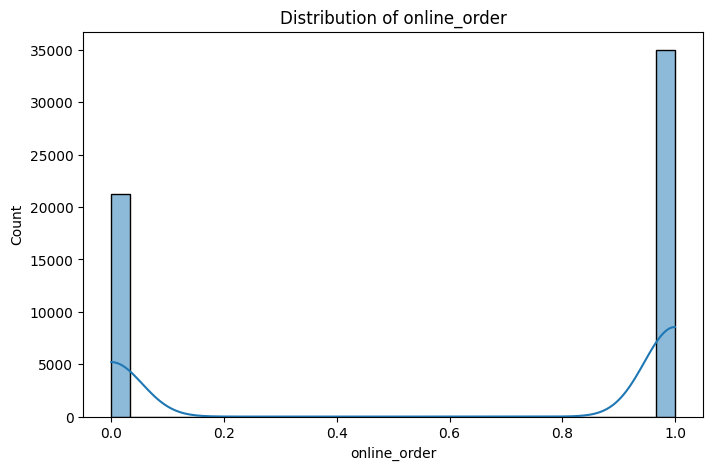

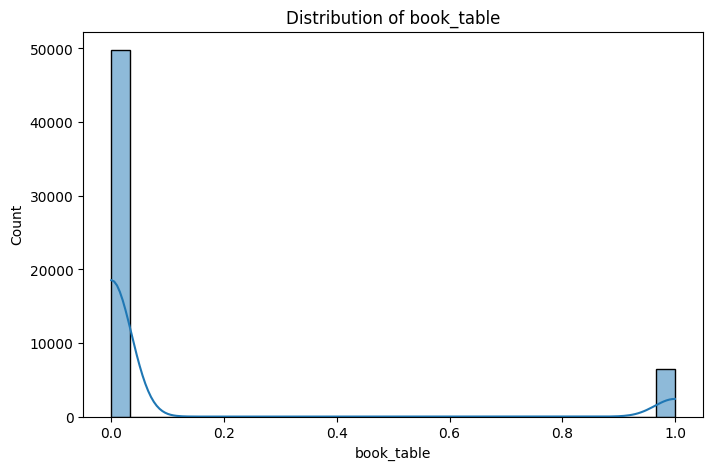

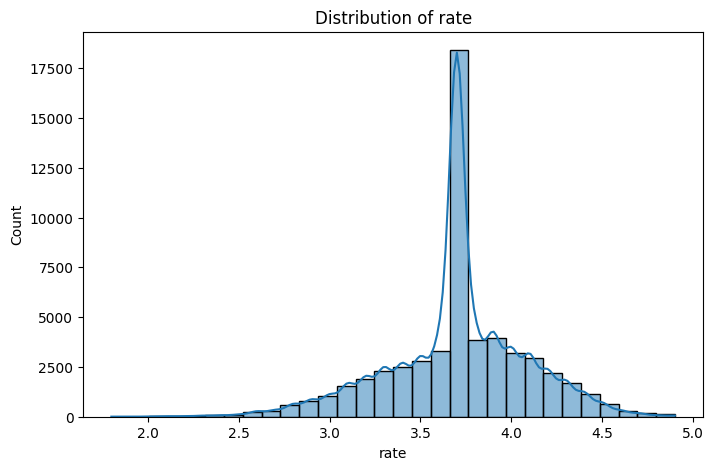

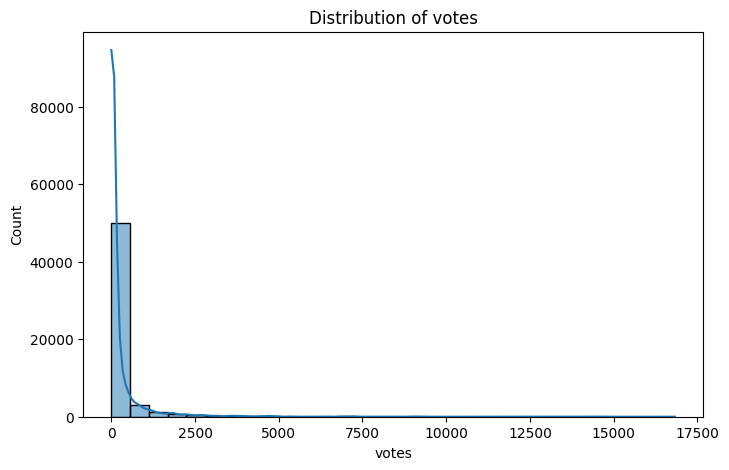

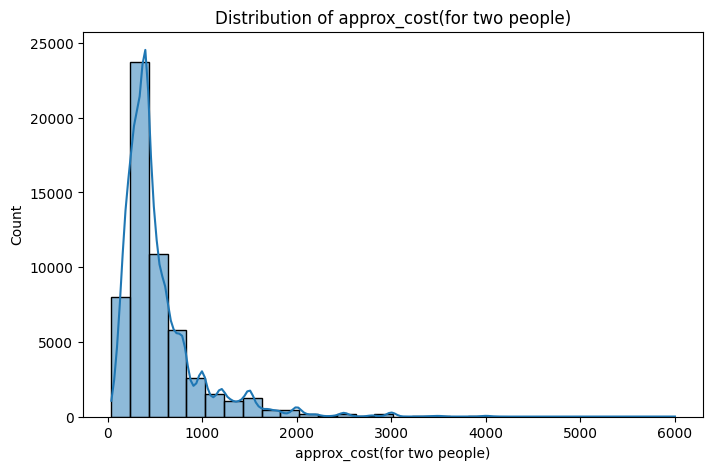

In [ ]:
# Plot histograms for the numerical columns
numerical_cols = ['online_order', 'book_table', 'rate', 'votes', 'approx_cost(for two people)']
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

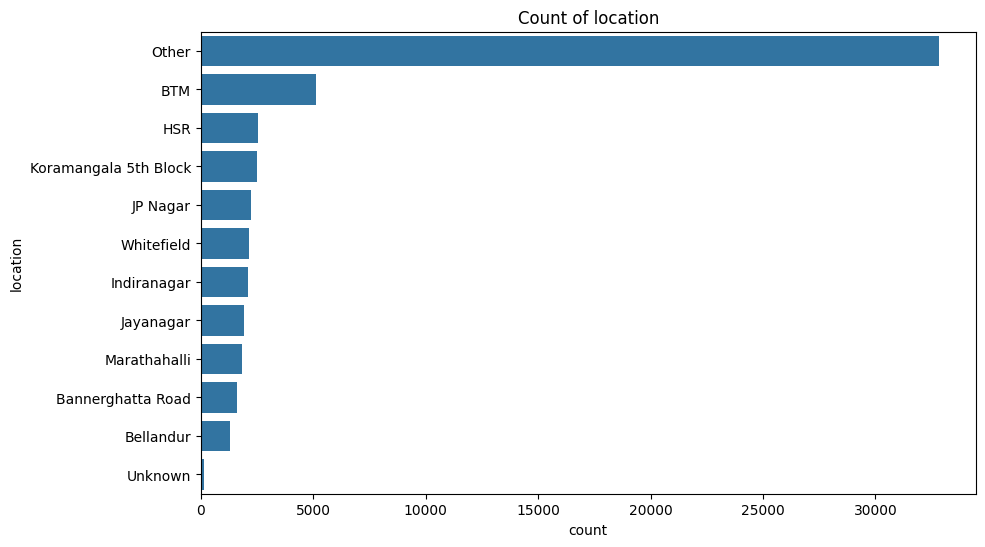

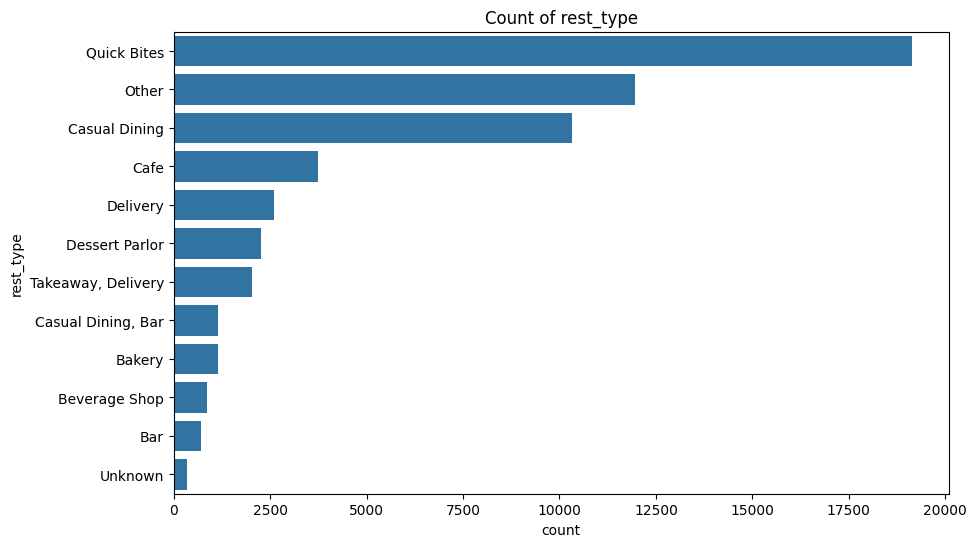

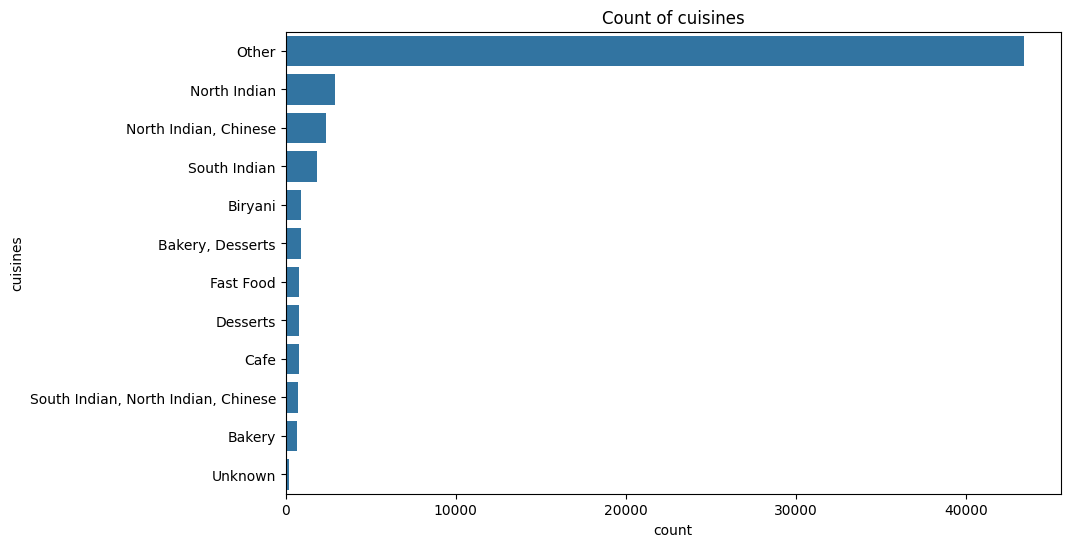

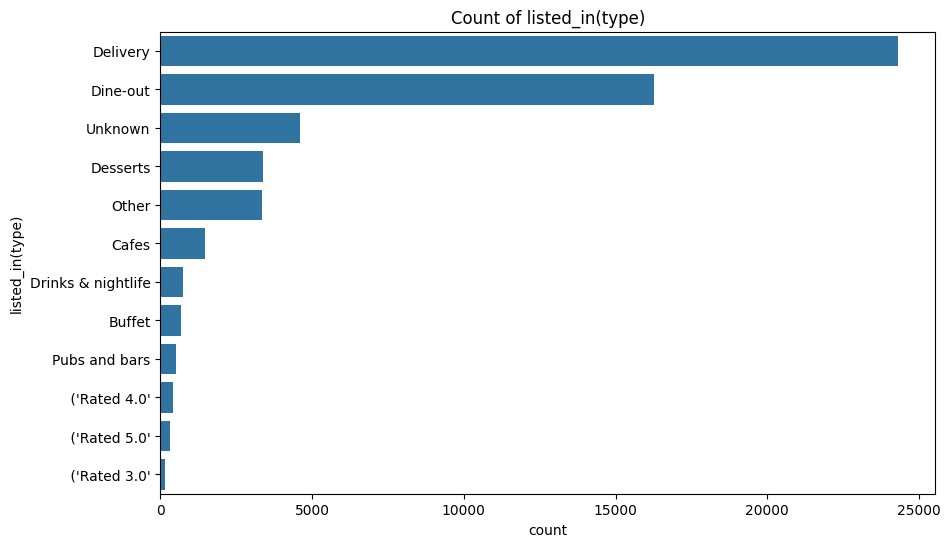

In [ ]:
# Plot count plots for the categorical columns
categorical_cols = ['location', 'rest_type', 'cuisines', 'listed_in(type)']
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(y=col, data=data, order=data[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.show()

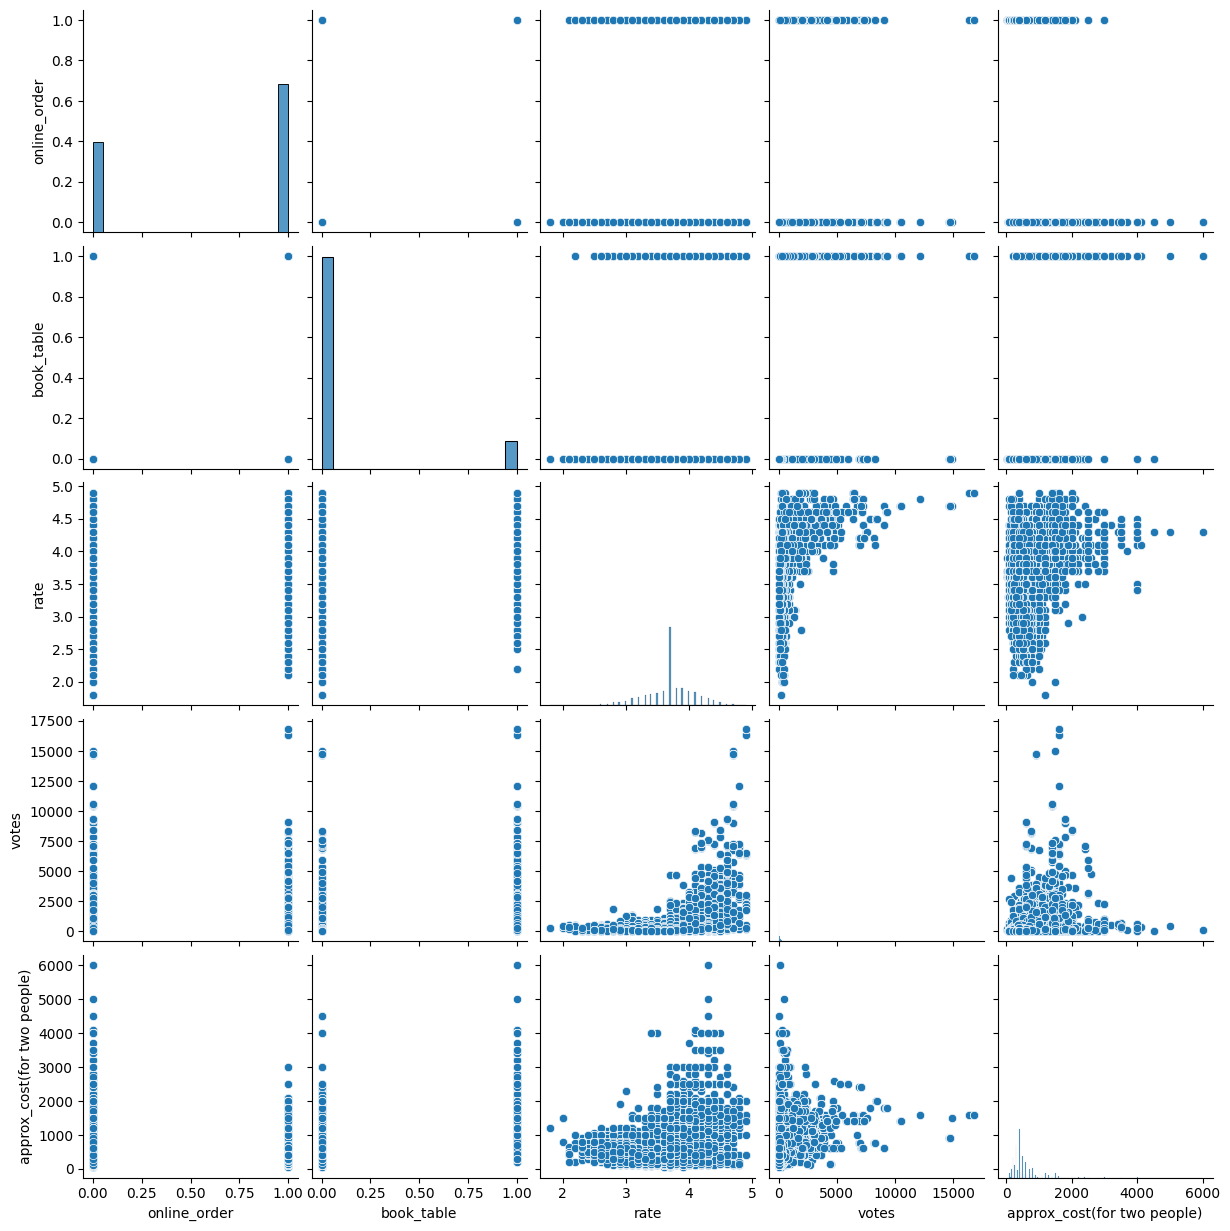

In [ ]:
# Create a pairplot for the numerical variables
sns.pairplot(data[numerical_cols])
plt.show()

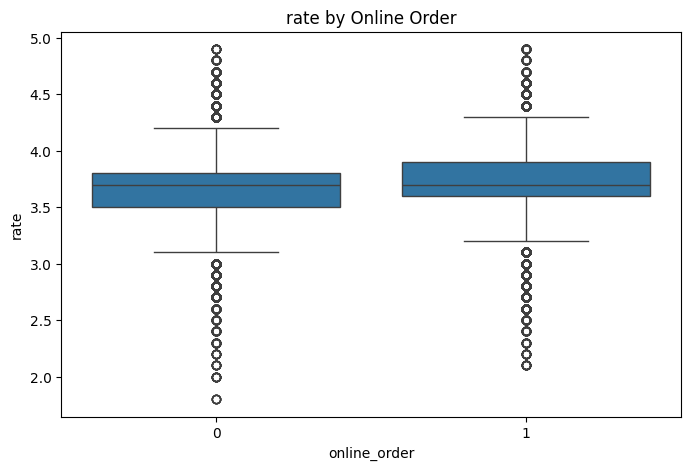

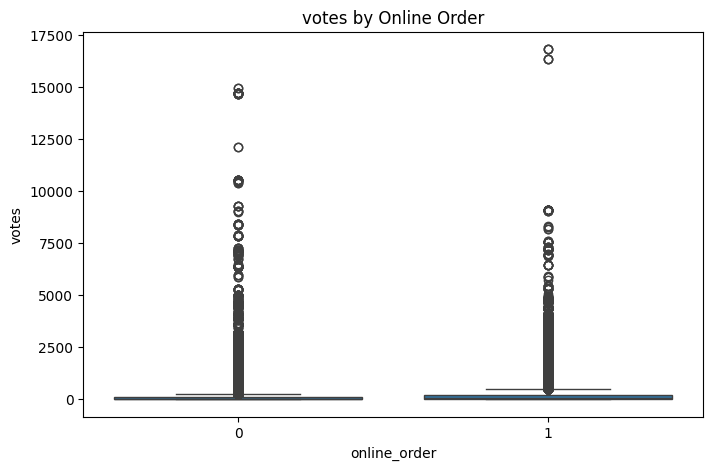

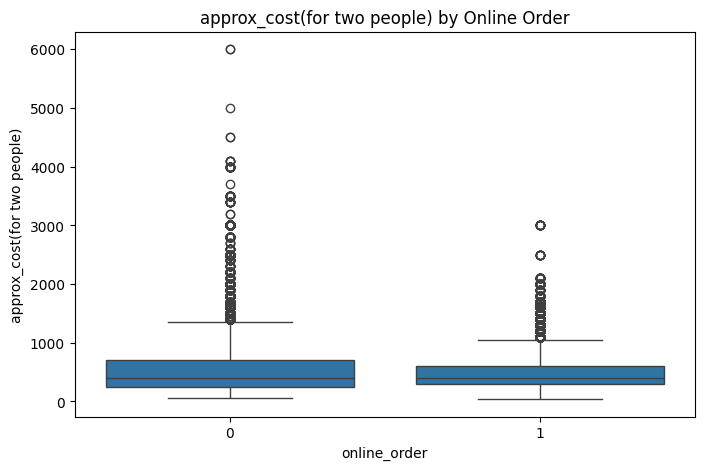

In [ ]:
# Create box plots to compare the distributions of 'rate', 'votes', and 'approx_cost(for two people)'
# for online order accepting and non-accepting restaurants
for col in ['rate', 'votes', 'approx_cost(for two people)']:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='online_order', y=col, data=data)
    plt.title(f'{col} by Online Order')
    plt.show()

In [ ]:
# Feature Engineering: Adding a new column 'expensive' based on the 'approx_cost(for two people)'
# We consider a restaurant as expensive if the cost for two people is higher than the median
median_cost = data['approx_cost(for two people)'].median()
data['expensive'] = data['approx_cost(for two people)'].apply(lambda x: 1 if x > median_cost else 0)

# Drop the original 'approx_cost(for two people)' column
data = data.drop(columns='approx_cost(for two people)')

# Check the first few rows of the dataframe
data.head()

,online_order,book_table,rate,votes,location,rest_type,cuisines,listed_in(type),expensive
0,1,1,4.1,775.0,Other,Casual Dining,Other,Buffet,1
1,1,0,4.1,787.0,Other,Casual Dining,Other,Buffet,1
2,1,0,3.8,918.0,Other,Other,Other,Buffet,1
3,0,0,3.7,88.0,Other,Quick Bites,Other,Buffet,0
4,0,0,3.8,166.0,Other,Casual Dining,Other,Buffet,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, TargetEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer # Import SimpleImputer

# --- Data Cleaning and Feature Engineering (before X and y split) ---
# Convert 'online_order' and 'book_table' to numerical (0 or 1) and fill any NaNs
data['online_order'] = data['online_order'].map({'Yes': 1, 'No': 0}).fillna(0).astype(float)
data['book_table'] = data['book_table'].map({'Yes': 1, 'No': 0}).fillna(0).astype(float)

# Convert 'rate' to numeric and handle remaining NaNs
data['rate'] = data['rate'].astype(str).str.replace('/5', '').str.strip().replace('', np.nan)
data['rate'] = pd.to_numeric(data['rate'], errors='coerce')
# Drop rows where the target 'rate' is NaN, as we can't train on them
data.dropna(subset=['rate'], inplace=True)

# Convert 'votes' to numeric, NaNs will be handled by SimpleImputer later, explicitly cast to float
data['votes'] = pd.to_numeric(data['votes'], errors='coerce').astype(float)

# Re-create 'expensive' feature to ensure consistency
# Clean 'approx_cost(for two people)' before use
data['approx_cost(for two people)'] = data['approx_cost(for two people)'].astype(str).str.replace(',', '', regex=False).str.strip().replace('', np.nan)
data['approx_cost(for two people)'] = pd.to_numeric(data['approx_cost(for two people)'], errors='coerce')

median_cost = data['approx_cost(for two people)'].median()
data['expensive'] = data['approx_cost(for two people)'].apply(lambda x: 1 if x > median_cost else 0)
# Ensure 'expensive' is float type
data['expensive'] = data['expensive'].astype(float)

# Drop the original 'approx_cost(for two people)' column, as 'expensive' is now derived
data = data.drop(columns='approx_cost(for two people)', errors='ignore')

# 1. Define X and y
# Drop 'phone' and 'dish_liked' as they are not used in the model and are of object type.
X = data.drop(['rate', 'phone', 'dish_liked'], axis=1, errors='ignore')
y = data['rate']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Create the Preprocessing Pipeline
# Log transform handles the 'long tail' in votes/cost seen in your EDA
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Imputes numerical NaNs
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

# TargetEncoder handles high-cardinality locations/cuisines
cat_pipe = TargetEncoder(target_type='continuous')

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, ['votes', 'expensive', 'online_order', 'book_table']),
    ('cat', cat_pipe, ['location', 'rest_type', 'cuisines', 'listed_in(type)'])
])

# 3. Full Pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# 4. Fit and Evaluate
model.fit(X_train, y_train)
print(f"New R2 Score: {model.score(X_test, y_test):.4f}")

New R2 Score: 0.8166


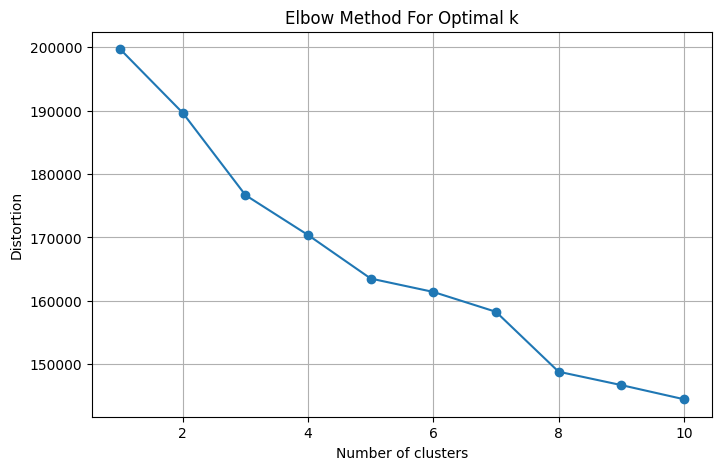

In [ ]:
# Determine the optimal number of clusters using the elbow method
distortions = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_scaled)
    distortions.append(kmeans.inertia_)

# Plot the elbow graph
plt.figure(figsize=(8, 5))
plt.plot(K, distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

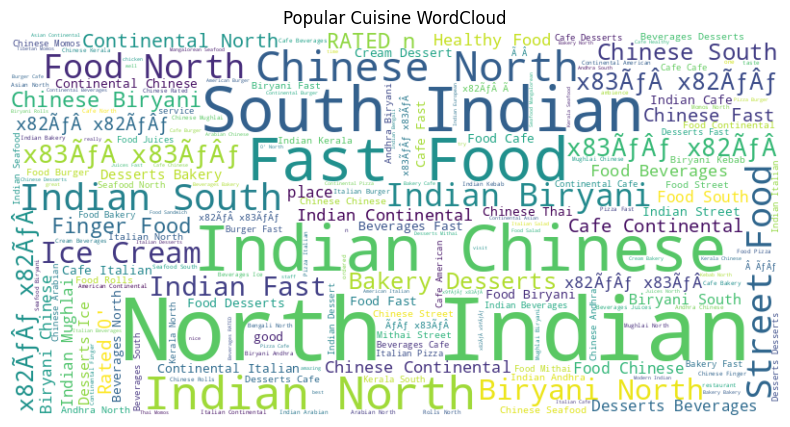

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(data['cuisines'].dropna().astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Popular Cuisine WordCloud")

plt.savefig("images/wordcloud.png")
plt.show()

In [6]:
import os

# Create the 'images' directory if it doesn't exist
output_dir = 'images'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

Created directory: images


In [ ]:
from sklearn.impute import SimpleImputer

# 1. Get the processed features from the regression pipeline
# This ensures the data is consistent with the cleaned `data` DataFrame (41665 rows)
X_processed_for_clustering = model.named_steps['preprocessor'].transform(X)

# 2. Impute any remaining NaNs in the processed data before clustering/PCA/t-SNE
# This addresses potential NaNs introduced by TargetEncoder for unseen categories
# and prepares the data for algorithms that don't handle NaNs (like KMeans, PCA, t-SNE)
imputer_for_clustering = SimpleImputer(strategy='mean')
X_processed_for_clustering_imputed = imputer_for_clustering.fit_transform(X_processed_for_clustering)

# Fit the K-Means model with 4 clusters on the fully processed and imputed data
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10) # n_init=10 to suppress future warning
kmeans.fit(X_processed_for_clustering_imputed)

# Get the cluster assignments for each instance
clusters = kmeans.labels_

# Add the cluster assignments to the dataframe.
# The length of `clusters` should now match `data`'s length.
data['cluster'] = clusters

# Display the first few rows of the dataframe
data.head()

,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,listed_in(type),expensive,cluster
0,0.0,0.0,4.1,775.0,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",Buffet,1.0,0
1,0.0,0.0,4.1,787.0,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",Buffet,1.0,0
2,0.0,0.0,3.8,918.0,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",Buffet,1.0,0
3,0.0,0.0,3.7,88.0,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",Buffet,0.0,2
4,0.0,0.0,3.8,166.0,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",Buffet,1.0,3


In [ ]:
# Calculate mean of numerical features for each cluster
numerical_cols = ['online_order', 'book_table', 'rate', 'votes', 'expensive']
cluster_means = data.groupby('cluster')[numerical_cols].mean()

# Calculate mode of categorical features for each cluster
categorical_cols = ['location', 'rest_type', 'cuisines', 'listed_in(type)']
cluster_modes = data.groupby('cluster')[categorical_cols].agg(lambda x: x.value_counts().index[0])

# Combine the mean and mode dataframes
cluster_characteristics = pd.concat([cluster_means, cluster_modes], axis=1)

cluster_characteristics

,online_order,book_table,rate,votes,expensive,location,rest_type,cuisines,listed_in(type)
cluster,,,,,,,,,
0,0.0,0.0,4.117052,1259.081502,1.0,Koramangala 5th Block,Casual Dining,North Indian,Delivery
1,0.0,0.0,3.442592,19.044380,0.0,BTM,Quick Bites,North Indian,Delivery
2,0.0,0.0,3.767674,235.411814,0.0,BTM,Quick Bites,North Indian,Delivery
3,0.0,0.0,3.596794,77.570365,1.0,BTM,Casual Dining,"North Indian, Chinese",Delivery


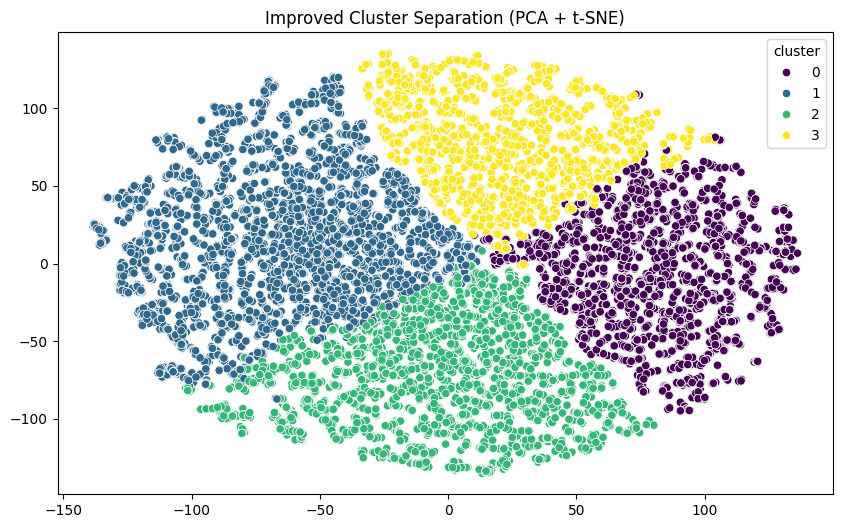

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Extract processed features from our pipeline (This step is technically already done in 4OLzFD75N1P3,
#    but we keep it for clarity if this cell were to be run independently after the pipeline setup)
X_processed = model.named_steps['preprocessor'].transform(X)

# 2. Reduce dimensions with PCA first (removes noise)
# Use the already imputed data prepared in cell 4OLzFD75N1P3
pca_data = PCA(n_components=5).fit_transform(X_processed_for_clustering_imputed)

# 3. Apply t-SNE for visualization
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(pca_data)

plt.figure(figsize=(10,6))
sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], hue=data['cluster'], palette='viridis')
plt.title("Improved Cluster Separation (PCA + t-SNE)")
plt.show()

In [ ]:
class AlfidoTechOptimizer:
    """
    A strategic module to implement growth and engagement
    recommendations for a tech-education platform.
    """

    def __init__(self, student_data, partner_data):
        self.students = student_data
        self.partners = partner_data

    # 1. RECOMMENDATION: AI-Driven "Skill-Match" Partnership Engine
    def partner_matching_system(self):
        """
        IDEA: Instead of manual placements, use a script to match interns
        with partner startups (like those in your Zomato analysis) based
        on their coding scores.
        """
        print("Recommendation 1: Automated Startup-Intern Matching Engine.")
        # Logic: Filter students with >80% score and match with tech partners
        top_talent = self.students[self.students['score'] > 85]
        matches = top_talent.merge(self.partners, on='required_skill')
        return matches

    # 2. RECOMMENDATION: "Data-to-Portfolio" Content Pipeline
    def portfolio_generator_tool(self):
        """
        IDEA: Provide students with code that automatically turns their
        project (e.g., Zomato Analysis) into a clean, hostable web portfolio.
        """
        print("Recommendation 2: Content Idea - Automated Portfolio Builder.")
        # Logic: Convert analysis results into a template for a personal website
        portfolio_status = "Generating HTML/CSS portfolio from Notebook results..."
        return portfolio_status

    # 3. RECOMMENDATION: Sentiment-Driven Content Improvement
    def content_quality_analysis(self, feedback_data):
        """
        IDEA: Use NLP to analyze intern feedback on projects. If a project
        (like 'Zomato Analysis') is too hard or too easy, the platform
        notifies the content team.
        """
        print("Recommendation 3: NLP-based Content Feedback Loop.")
        # Logic: Flag projects with negative sentiment for manual review
        low_engagement_projects = feedback_data[feedback_data['sentiment'] < 0.2]
        return low_engagement_projects

    # 4. RECOMMENDATION: Industry Capstone Sponsorships
    def sponsor_roi_dashboard(self):
        """
        IDEA: Partner with companies to provide 'Live Datasets'.
        The code generates a report for the sponsor showing how many
        interns solved their specific business problems.
        """
        print("Recommendation 4: Partnership - Live Business Case Sponsorship.")
        # Logic: Group solutions by problem_id to show sponsor impact
        impact_report = self.students.groupby('problem_id')['solved'].sum()
        return impact_report

    # 5. RECOMMENDATION: Gamified "Code-Streak" Engagement
    def engagement_gamification(self):
        """
        IDEA: Create a 'Code-Streak' feature similar to Duolingo.
        Content: Daily 'Mini-Fix' challenges where interns debug 1 line of code.
        """
        print("Recommendation 5: Content - Gamified Daily Debugging Challenges.")
        # Logic: Track consecutive days of login/commit
        streaks = self.students[['student_id', 'consecutive_days']]
        return streaks

# --- Implementation Example ---
# Mock Data
students = pd.DataFrame({'student_id': [1, 2], 'score': [90, 75],
                         'required_skill': ['Python', 'Excel'], 'problem_id': ['Zomato', 'Zomato'],
                         'solved': [1, 1], 'consecutive_days': [5, 2]})
partners = pd.DataFrame({'partner_name': ['StartupX'], 'required_skill': ['Python']})

# Initialize the platform strategy
platform = AlfidoTechOptimizer(students, partners)

# Execute one of the recommendations
matched_interns = platform.partner_matching_system()
print(matched_interns)

Recommendation 1: Automated Startup-Intern Matching Engine.
   student_id  score required_skill problem_id  solved  consecutive_days  \
0           1     90         Python     Zomato       1                 5   

  partner_name  
0     StartupX  
